In [1]:
import numpy as np
from pathlib import Path

from fontTools.diff import color
from matplotlib.pyplot import xlim
from numpy.ma.core import size

DATA_DIR = Path(r"C:\Users\asus\PycharmProjects\UltrasonicProject_ML\data")

data = np.load(
    DATA_DIR / "Pk050_3D_Dataset_Long_Rot00.npy",
    mmap_mode="r"
)

X = np.load(DATA_DIR / "X-values.npy")
Y = np.load(DATA_DIR / "Y-values.npy")
Z = np.load(DATA_DIR / "Z-values.npy")

valid_mask = np.any(data != 0, axis=2)

## Get features

In [2]:
from scipy.stats import skew , kurtosis

feature = []    # the data features

### find the features ###
for i in range(0, len(X)):
    for j in range(0, len(Y)):

        if not valid_mask[i, j]:   # break the loop
            continue
        a_scan = data[i, j, :]

        ## make the feature
        rms = np.sqrt(np.mean(a_scan**2))
        maximum = np.max(np.abs(a_scan))
        mean= np.mean(a_scan)
        std = np.std(a_scan)
        peak_to_peak = np.ptp(a_scan)
        energy = np.sum(a_scan**2)

        ## add to feature list
        feature.append([X[i], Y[j], rms, maximum, mean, std, peak_to_peak, energy])


In [3]:
import pandas as pd

### make dataframe ###
df = pd.DataFrame(
    feature,
    columns=[
        "X",
        "Y",
        "RMS",
        "Maximum",
        "Mean",
        "Std",
        "PeakToPeak",
        "Energy"
    ]
)

print(df.head())
print(df.describe())

    X   Y          RMS  Maximum      Mean          Std  PeakToPeak  \
0  70  50  1996.775302  11756.0  26.42950  1996.600383     19466.0   
1  70  60  1970.613188  11158.0 -35.87500  1970.286609     20361.0   
2  70  70  1643.562562  11498.0 -29.99225  1643.288885     20510.0   
3  70  80  1537.076423   9862.0  17.26975  1536.979403     17864.0   
4  70  90  1558.708448  11475.0  10.69425  1558.671762     19895.0   

         Energy  
0  1.594845e+10  
1  1.553327e+10  
2  1.080519e+10  
3  9.450416e+09  
4  9.718288e+09  
                  X             Y           RMS       Maximum          Mean  \
count  13277.000000  13277.000000  13277.000000  13277.000000  13277.000000   
mean    1000.000000    400.000000   1227.647245  10326.000226      3.084888   
std      539.835113    204.946734    369.539437   2408.354906     32.722695   
min       70.000000     50.000000    476.855490   3477.000000   -716.858250   
25%      530.000000    220.000000    957.968081   8568.000000    -14.206250 

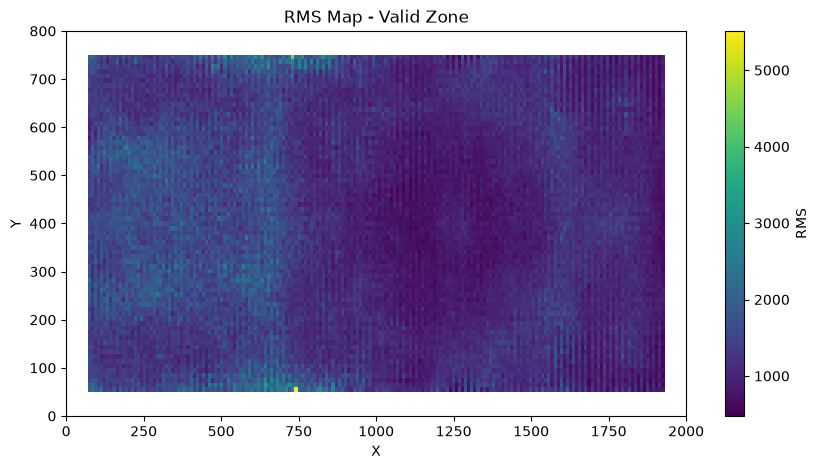

In [4]:
import matplotlib.pyplot as plt
rms_map = np.full(valid_mask.shape, np.nan)

for i in range(len(X)):
    for j in range(len(Y)):

        if valid_mask[i, j]:
            a_scan = data[i, j, :]
            rms_map[i, j] = np.sqrt(np.mean(a_scan**2))

plt.figure(figsize=(10, 5))

plt.imshow(
    rms_map.T,
    origin="lower",
    aspect="auto",
    extent=[X.min(), X.max(), Y.min(), Y.max()]
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("RMS Map - Valid Zone")
plt.colorbar(label="RMS")

plt.show()

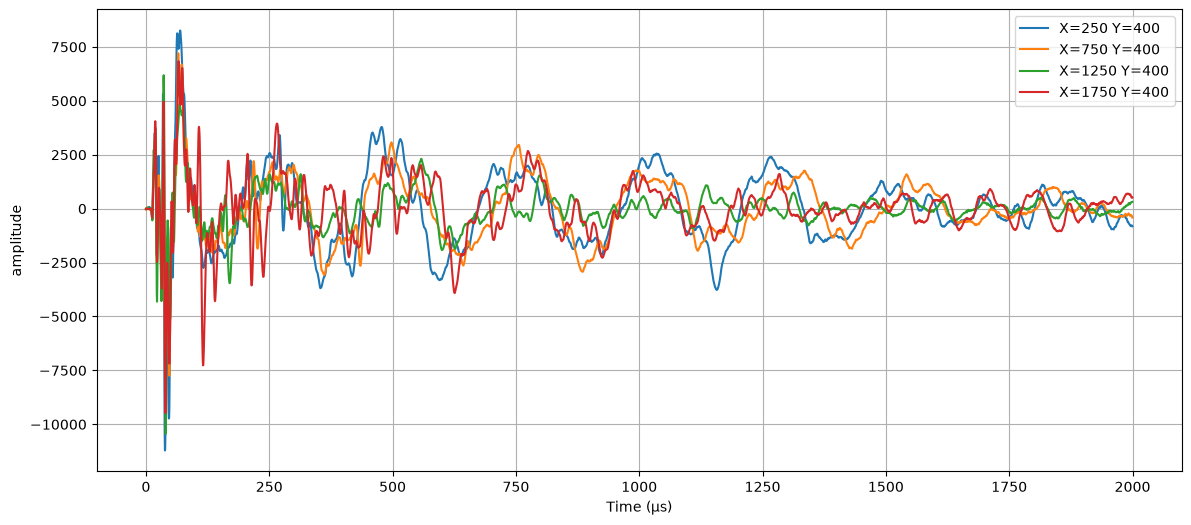

In [5]:
positions = [
    (25, 40),
    (75, 40),
    (125, 40),
    (175, 40)
]

plt.figure( figsize=(14, 6) )
for i in positions:
    a_scan = data[i[0], i[1], :]
    plt.plot(
        Z,
        a_scan,
        label=f"X={X[i[0]]} Y={Y[i[1]]}",
    )

plt.xlabel("Time (µs)")
plt.ylabel("amplitude")

plt.grid()
plt.legend()

plt.savefig("XY_Map_Valid_Zone.png")
plt.show()



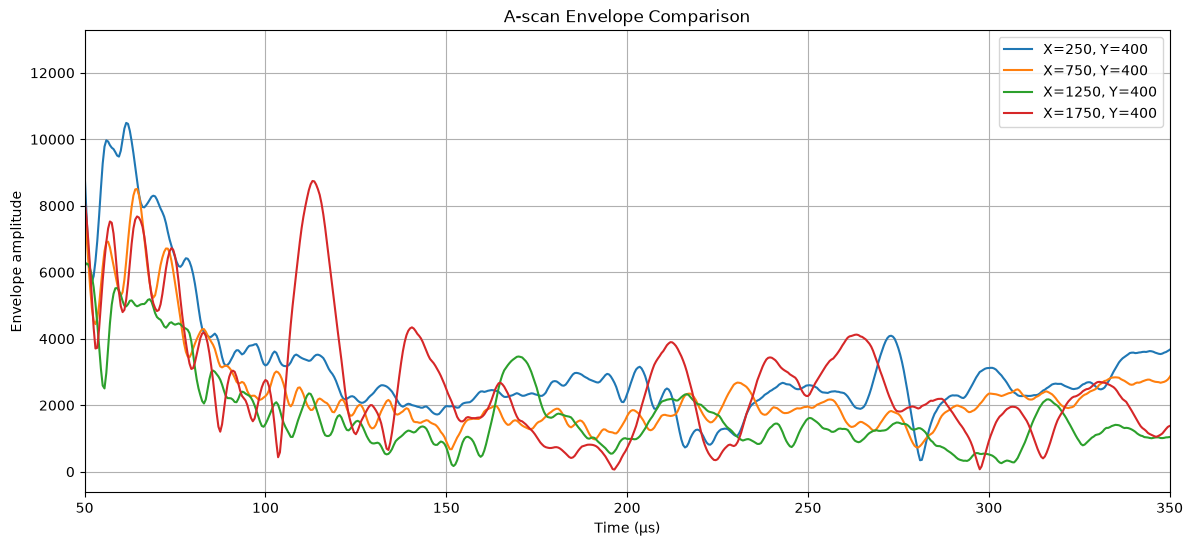

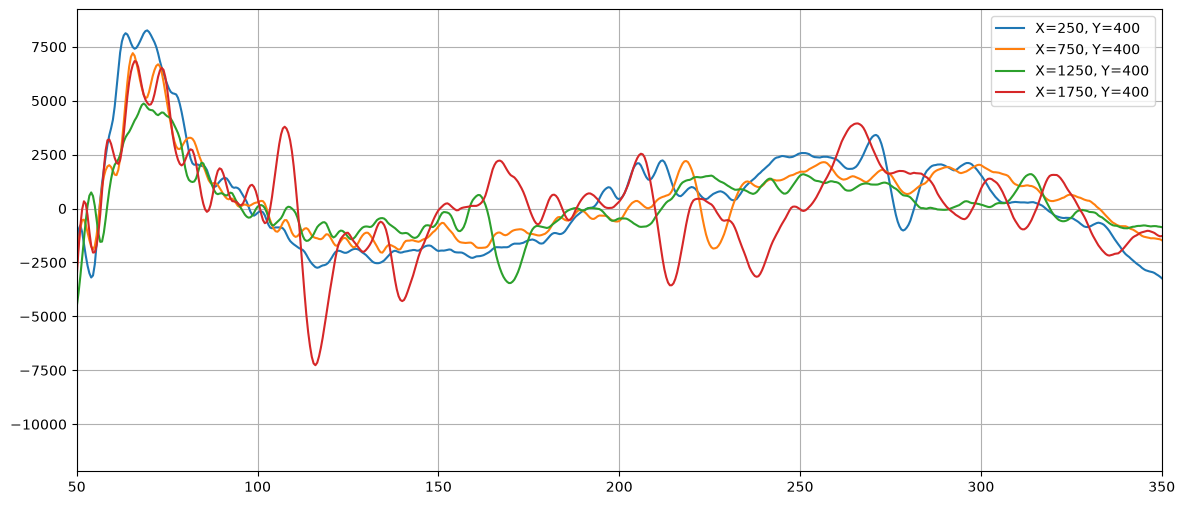

In [6]:
from scipy.signal import hilbert
import numpy as np
import matplotlib.pyplot as plt

positions = [
    (250, 400),
    (750, 400),
    (1250, 400),
    (1750, 400)
]

plt.figure(figsize=(14, 6))

for x, y in positions:

    a_scan = data[np.where(X == x)[0][0],
                  np.where(Y == y)[0][0],
                  :]

    analytic_signal = hilbert(a_scan)
    envelope = np.abs(analytic_signal)

    time = np.arange(len(a_scan)) * 0.5  # μs

    plt.plot(time, envelope, label=f"X={x}, Y={y}")

plt.xlabel("Time (μs)")
plt.ylabel("Envelope amplitude")
plt.title("A-scan Envelope Comparison")
plt.legend()
plt.grid()


plt.xlim(50, 350)
plt.show()


plt.figure(figsize=(14, 6))
for x, y in positions:

    a_scan = data[np.where(X == x)[0][0],
                  np.where(Y == y)[0][0],
                  :]

    time = np.arange(len(a_scan)) * 0.5  # μs

    plt.plot(time, a_scan, label=f"X={x}, Y={y}")

plt.grid()
plt.legend()
plt.xlim(50, 350)
plt.savefig("find backwall.png")
plt.show()

| X    |    ضخامت | زمان مورد انتظار با (v≈4000) m/s |
| ---- | -------: | -------------------------------: |
| 250  | 571.3 mm |                          ≈286 µs |
| 750  | 452.0 mm |                          ≈226 µs |
| 1250 | 330.9 mm |                          ≈165 µs |
| 1750 | 210.8 mm |                          ≈105 µs |


X=250: estimated=286 µs, peak=289.0 µs, amplitude=2047.0
X=750: estimated=226 µs, peak=218.5 µs, amplitude=2204.0
X=1250: estimated=165 µs, peak=169.5 µs, amplitude=-3455.0
X=1750: estimated=105 µs, peak=113.0 µs, amplitude=-3967.0


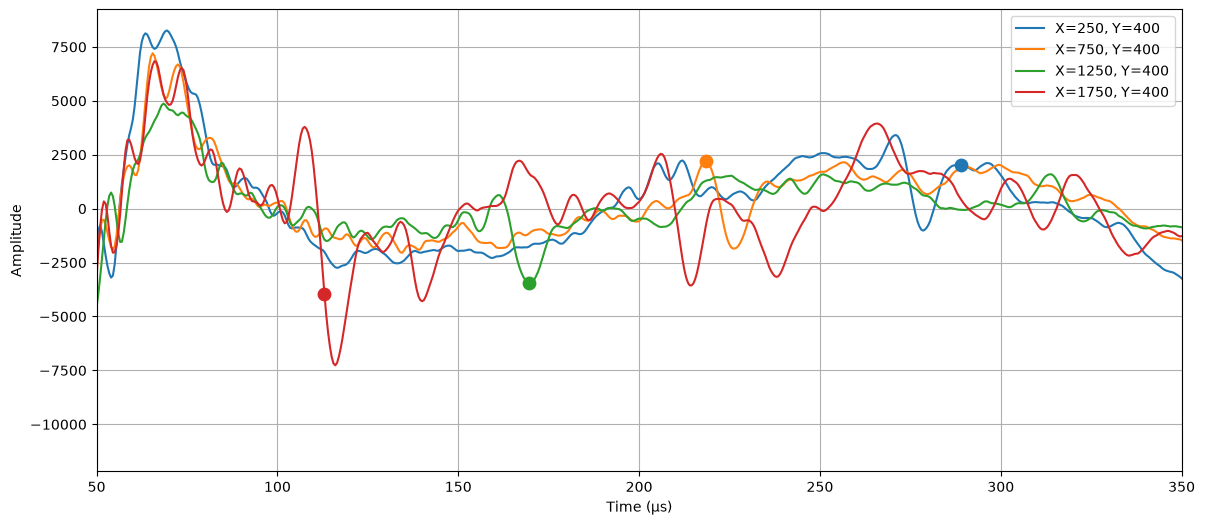

In [7]:
positions = [
    (250, 400, 286),
    (750, 400, 226),
    (1250, 400, 165),
    (1750, 400, 105)
]
time = np.arange(len(Z)) * 0.5
plt.figure(figsize=(14, 6))

for x, y, t_bw in positions:
    a_scan = data[
        np.where(X == x)[0][0],
        np.where(Y == y)[0][0],
        :
    ]

    plt.plot(time, a_scan,
             label=f"X={x}, Y={y}")

    sample_index = int(t_bw / 0.5)

    window = (time >= t_bw - 8) & (time <= t_bw + 8)

    peak_index = np.where(window)[0][
        np.argmax(np.abs(a_scan[window]))
    ]

    peak_time = time[peak_index]
    peak_amplitude = a_scan[peak_index]

    print(
        f"X={x}: "
        f"estimated={t_bw} µs, "
        f"peak={peak_time} µs, "
        f"amplitude={peak_amplitude}"
    )

    plt.scatter(
        peak_time,
        peak_amplitude,
        s=80,
        zorder=5
    )

plt.xlim(50, 350)
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.savefig("find peak.png")
plt.show()

| X    |    ضخامت | زمان مورد انتظار با (v≈4000) m/s |
| ---- | -------: | -------------------------------: |
| 250  | 571.3 mm |                          ≈286 µs |
| 750  | 452.0 mm |                          ≈226 µs |
| 1250 | 330.9 mm |                          ≈165 µs |
| 1750 | 210.8 mm |                          ≈105 µs |



X=250: guess=286 µs | detected=273.0 µs | estimated_speed=3995.1 | real_speed=4185.35

X=750: guess=226 µs | detected=230.5 µs | estimated_speed=4000.0 | real_speed=3921.91

X=1250: guess=165 µs | detected=170.0 µs | estimated_speed=4010.91 | real_speed=3892.94

X=1750: guess=105 µs | detected=113.0 µs | estimated_speed=4015.24 | real_speed=3730.97


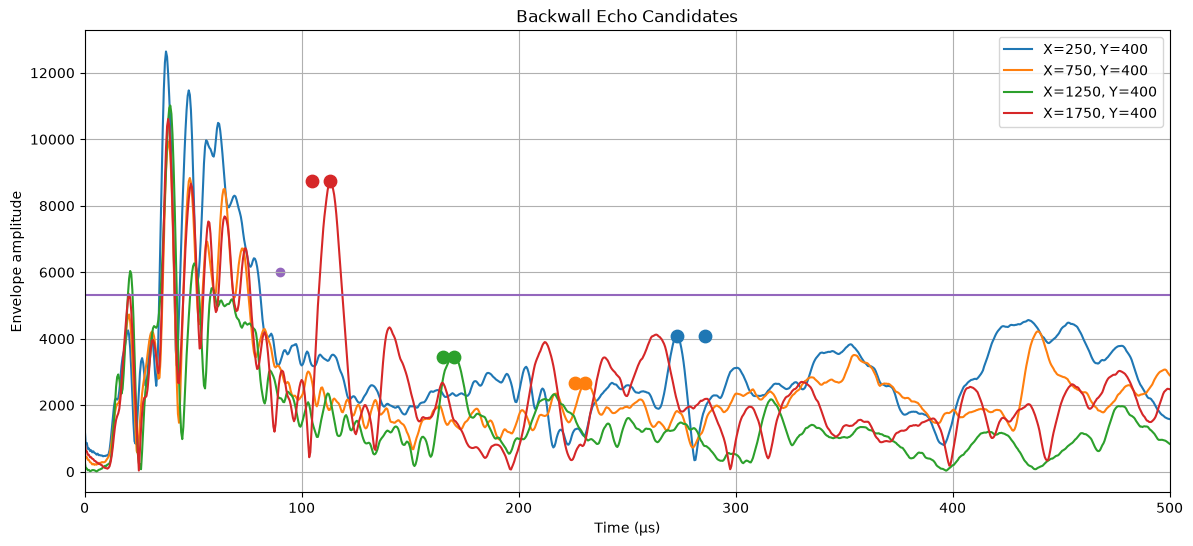

In [25]:
from scipy.signal import hilbert
import numpy as np
import matplotlib.pyplot as plt

positions = [
    (250, 400, 286, 571.3),
    (750, 400, 226, 452.0),
    (1250, 400, 165, 330.9),
    (1750, 400, 105, 210.8)
]

time = np.arange(len(Z)) * 0.5

plt.figure(figsize=(14, 6))

for x, y, t_guess, d in positions:

    i = np.where(X == x)[0][0]
    j = np.where(Y == y)[0][0]

    a_scan = data[i, j, :]

    # Envelope
    envelope = np.abs(hilbert(a_scan))

    # محدوده جستجو ±15 µs
    mask = (time >= t_guess - 15) & (time <= t_guess + 15)

    candidate_indices = np.where(mask)[0]

    # قوی‌ترین نقطه در Envelope
    peak_index = candidate_indices[
        np.argmax(envelope[candidate_indices])
    ]

    peak_time = time[peak_index]

    plt.plot(
        time,
        envelope,
        label=f"X={x}, Y={y}"
    )

    t = [peak_time, t_guess]


    plt.scatter(
        t,
        [envelope[peak_index], envelope[peak_index]],
        s=80,
        zorder=5
    )

    print(
        f"\nX={x}: "
        f"guess={t_guess} µs | "
        f"detected={peak_time} µs | "
        f"estimated_speed={((2*d)*1000/t_guess).__round__(2)} | "
        f"real_speed={((2*d)*1000/peak_time).__round__(2)}"
    )

peak = np.ones(len(time))*(int(np.max(envelope)/2))
plt.scatter(90, 6000)
plt.plot(time, peak)
plt.xlim(0, 500)
plt.xlabel("Time (µs)")
plt.ylabel("Envelope amplitude")
plt.title("Backwall Echo Candidates")
plt.grid()
plt.legend()
plt.show()

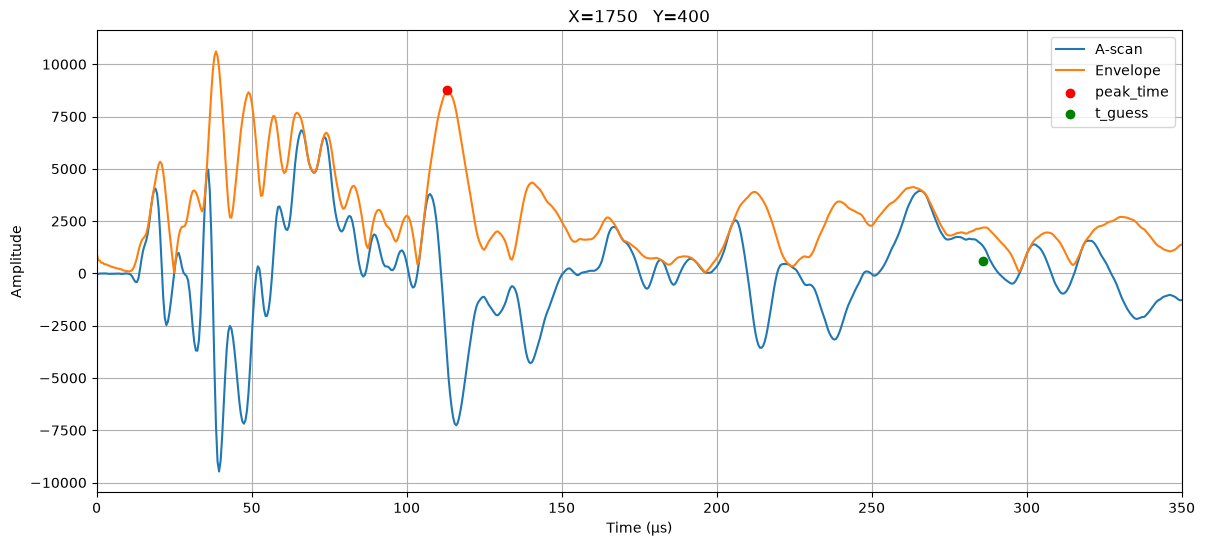

In [12]:
point = (1750, 400, 105, 210.8)

a_scan = data[
    np.where(X == point[0])[0][0],
    np.where(Y == point[1])[0][0],
    :
]

# زمان/اندیس نمونه‌ها
time = np.arange(len(a_scan)) * 0.5

plt.figure(figsize=(14, 6))

# A-scan
plt.plot(time, a_scan, label="A-scan")

# Envelope
envelope = np.abs(hilbert(a_scan))
plt.plot(time, envelope, label="Envelope")

# محدوده‌ی جستجوی قله
window = (time >= point[2] - 15) & (time <= point[2] + 15)

# پیدا کردن قله در همین محدوده
local_peak_index = np.argmax(envelope[window])

# تبدیل اندیس محلی به اندیس اصلی آرایه
peak_index = np.where(window)[0][local_peak_index]

peak_time = time[peak_index]
peak_amplitude = envelope[peak_index]

# نمایش قله
plt.scatter(
    peak_time,
    peak_amplitude,
    zorder=5,
    color='red',
    label="peak_time"
)

plt.scatter(
    286,
    286*2,
    zorder=5,
    color='green',
    label="t_guess"
)

plt.legend()
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.title(f"X={point[0]}   Y={point[1]}")
plt.grid()
plt.xlim(0, 350)
plt.savefig(f"peak{point[0]}.png")
plt.show()

slope = 0.4495 µs/mm
intercept = 20.7498 µs
R² = 0.9952


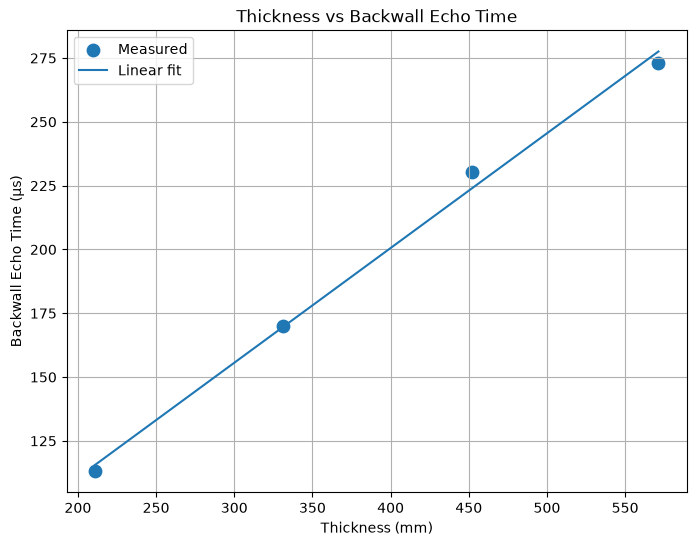

In [10]:
import numpy as np
import matplotlib.pyplot as plt

thickness = np.array([
    571.3,
    452.0,
    330.9,
    210.8
])

peak_time = np.array([
    273.0,
    230.5,
    170.0,
    113.0
])

# Linear fit
slope, intercept = np.polyfit(thickness, peak_time, 1)

predicted_time = slope * thickness + intercept

# R²
ss_res = np.sum((peak_time - predicted_time) ** 2)
ss_tot = np.sum((peak_time - np.mean(peak_time)) ** 2)

r2 = 1 - ss_res / ss_tot

print(f"slope = {slope:.4f} µs/mm")
print(f"intercept = {intercept:.4f} µs")
print(f"R² = {r2:.4f}")

plt.figure(figsize=(8, 6))

plt.scatter(
    thickness,
    peak_time,
    s=80,
    label="Measured"
)

plt.plot(
    thickness,
    predicted_time,
    label="Linear fit"
)

plt.xlabel("Thickness (mm)")
plt.ylabel("Backwall Echo Time (µs)")
plt.title("Thickness vs Backwall Echo Time")

plt.grid()
plt.legend()
plt.savefig("Thickness vs Backwall Echo Time.png")
plt.show()

RMS: 3306.0723738272286
Mean: -715.2950819672132
Standard deviation: 3227.765091622549
Max amplitude: 7264.0
Peak-to-peak: 11058.0
Energy: 666736987.0
Envelope maximum: 8745.172944454347
Backwall TOF: 113.0
Backwall amplitude: -3967.0


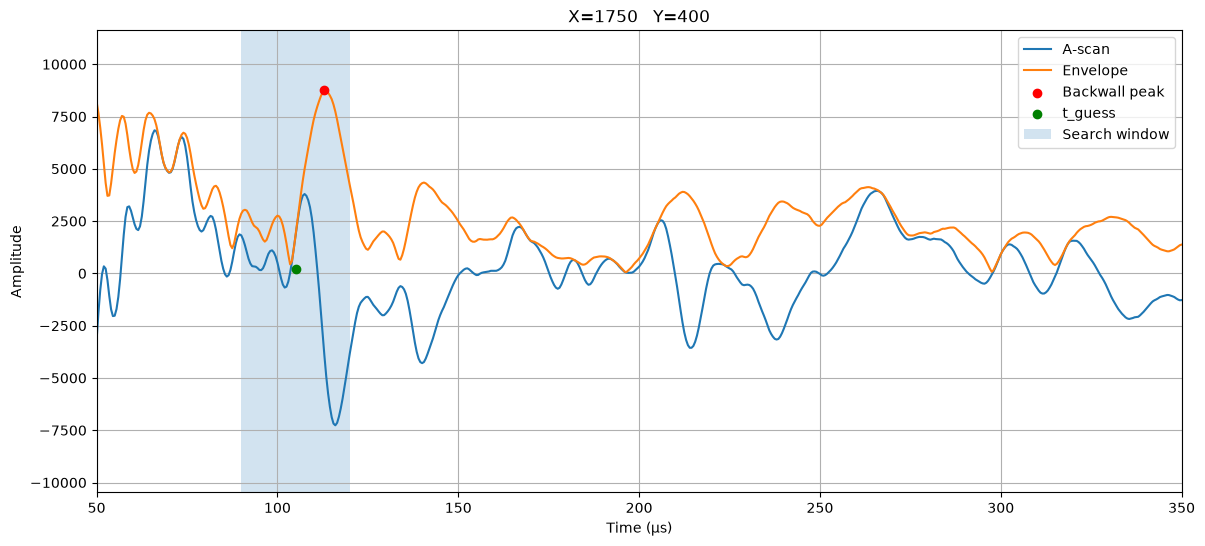

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

point = (1750, 400, 105, 210.8)

# -------------------------
# Get A-scan
# -------------------------

a_scan = data[
    np.where(X == point[0])[0][0],
    np.where(Y == point[1])[0][0],
    :
]

# Time axis
time = np.arange(len(a_scan)) * 0.5

# -------------------------
# Envelope
# -------------------------

envelope = np.abs(hilbert(a_scan))

# -------------------------
# Backwall search window
# -------------------------

window = (time >= point[2] - 15) & (time <= point[2] + 15)

window_signal = a_scan[window]
window_envelope = envelope[window]
window_time = time[window]

# -------------------------
# Features
# -------------------------

# 1. RMS
rms = np.sqrt(np.mean(window_signal ** 2))

# 2. Mean
mean = np.mean(window_signal)

# 3. Standard deviation
std = np.std(window_signal)

# 4. Maximum amplitude
max_amplitude = np.max(np.abs(window_signal))

# 5. Peak-to-peak
peak_to_peak = np.ptp(window_signal)

# 6. Energy
energy = np.sum(window_signal ** 2)

# 7. Envelope maximum
envelope_maximum = np.max(window_envelope)

# 8. Backwall TOF
peak_index = np.argmax(window_envelope)

backwall_tof = window_time[peak_index]

# 9. Backwall amplitude
backwall_amplitude = window_signal[peak_index]

# -------------------------
# Print features
# -------------------------

print("RMS:", rms)
print("Mean:", mean)
print("Standard deviation:", std)
print("Max amplitude:", max_amplitude)
print("Peak-to-peak:", peak_to_peak)
print("Energy:", energy)
print("Envelope maximum:", envelope_maximum)
print("Backwall TOF:", backwall_tof)
print("Backwall amplitude:", backwall_amplitude)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(14, 6))

plt.plot(time, a_scan, label="A-scan")
plt.plot(time, envelope, label="Envelope")

# Backwall peak
plt.scatter(
    backwall_tof,
    envelope_maximum,
    color="red",
    zorder=5,
    label="Backwall peak"
)

# Guess
plt.scatter(
    point[2],
    point[3],
    color="green",
    zorder=5,
    label="t_guess"
)

# Search window
plt.axvspan(
    point[2] - 15,
    point[2] + 15,
    alpha=0.2,
    label="Search window"
)

plt.legend()
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.title(f"X={point[0]}   Y={point[1]}")
plt.grid()

plt.xlim(50, 350)

plt.savefig(f"peak{point[0]}.png")
plt.show()